# Fixed Beamforming: Mathematical Intuition and Implementation

This notebook provides a comprehensive understanding of fixed beamforming techniques with:
- Mathematical foundations with step-by-step derivations
- Visual intuition through extensive plots and animations
- Practical implementation with 2-microphone arrays
- Interactive demonstrations

**Topics Covered:**
1. Physics of sound propagation and time delays
2. Delay-and-Sum beamforming
3. Beam pattern visualization (polar plots)
4. Weighted beamforming with complex weights
5. Practical 2-mic array examples

---

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Constants
SPEED_OF_SOUND = 343  # m/s at 20°C
SAMPLE_RATE = 16000   # Hz

print("✓ Libraries imported successfully!")
print(f"✓ Speed of sound: {SPEED_OF_SOUND} m/s")
print(f"✓ Sample rate: {SAMPLE_RATE} Hz")

✓ Libraries imported successfully!
✓ Speed of sound: 343 m/s
✓ Sample rate: 16000 Hz


---
## 1. What is Beamforming?

**Beamforming** is a spatial filtering technique that uses multiple microphones to:
- ✅ **Enhance signals** from a desired direction (e.g., speaker's voice)
- ✅ **Suppress signals** from other directions (e.g., noise sources)

### Analogy: Directional Flashlight for Sound

```
Regular Microphone:        Beamformer:
   Hears everything           Focuses on target
        ↓ ↓ ↓                      ↓
       ↓ ● ↓                      ╱│╲
        ↓ ↓ ↓                    ╱ │ ╲
                                ╱  ●  ╲
```

### Key Principle: Spatial Coherence

- **Speech (target)**: Arrives from one direction → **coherent** across microphones
- **Noise (ambient)**: Arrives from all directions → **incoherent** across microphones

Beamforming exploits this difference!

---

## 2. Physics of Sound Propagation and Time Delays

### 2.1 The Fundamental Problem

When a sound source is at an angle θ, it reaches different microphones at **different times**:

```
Sound Source (angle θ)
        ↓
       /  \
      /    \
     /      \
  Mic1      Mic2
  ├─────d───┤
```

### Mathematical Formulation

**Time delay between microphones:**

$$\tau = \frac{d \cdot \sin(\theta)}{c}$$

Where:
- $d$ = microphone spacing (meters)
- $\theta$ = angle of arrival (degrees, 0° = front)
- $c$ = speed of sound (343 m/s)
- $\tau$ = time delay (seconds)

**In samples:**

$$\tau_{samples} = \tau \cdot f_s = \frac{d \cdot \sin(\theta) \cdot f_s}{c}$$

---




In [2]:
# Function to calculate time delay
def calculate_time_delay(d, theta_deg, c=SPEED_OF_SOUND):
    """
    Calculate time delay between two microphones.
    
    Args:
        d: Microphone spacing (meters)
        theta_deg: Angle of arrival (degrees, 0° = front)
        c: Speed of sound (m/s)
    
    Returns:
        tau: Time delay (seconds)
        tau_samples: Time delay (samples at SAMPLE_RATE)
    """
    theta_rad = np.radians(theta_deg)
    tau = (d * np.sin(theta_rad)) / c
    tau_samples = int(tau * SAMPLE_RATE)
    return tau, tau_samples

# Example: 5cm spacing, 30° angle
d = 0.05  # 5cm
theta = 30  # degrees

tau, tau_samples = calculate_time_delay(d, theta)

print(f"Microphone spacing: {d*100:.1f} cm")
print(f"Angle of arrival: {theta}°")
print(f"Time delay: {tau*1e6:.2f} μs")
print(f"Delay in samples (at {SAMPLE_RATE} Hz): {tau_samples} samples")
print(f"Delay in milliseconds: {tau*1000:.3f} ms")

Microphone spacing: 5.0 cm
Angle of arrival: 30°
Time delay: 72.89 μs
Delay in samples (at 16000 Hz): 1 samples
Delay in milliseconds: 0.073 ms


### 2.2 Visualizing Time Delays

Let's visualize how a sound wave arrives at two microphones from different angles.

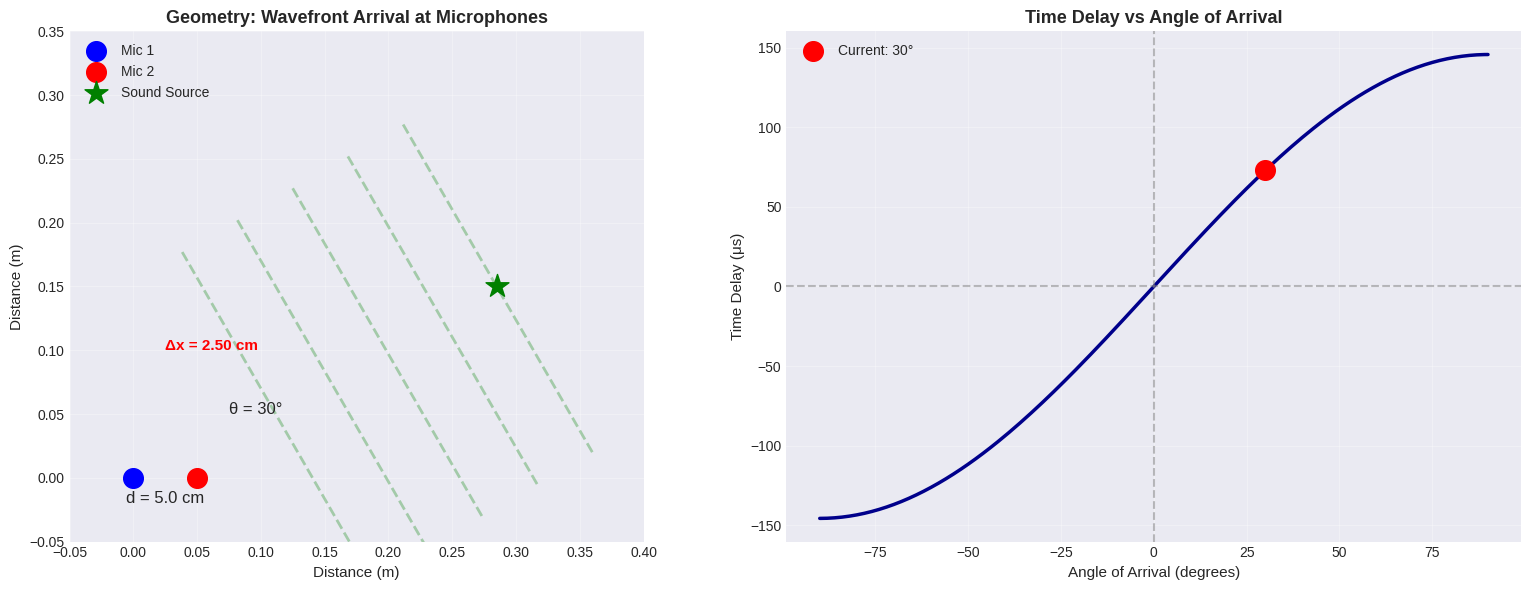


CALCULATIONS:
Path difference: Δx = d·sin(θ) = 0.05·sin(30°) = 2.500 cm
Time delay: τ = Δx/c = 0.0250/343 = 72.89 μs
Samples delay: τ_samples = τ·fs = 72.89μs · 16000Hz = 1 samples


In [3]:
def visualize_time_delay_geometry(d=0.05, theta_deg=30):
    """
    Visualize the geometry of time delays for a 2-mic array.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Geometry
    ax = axes[0]
    
    # Microphone positions
    mic1_pos = np.array([0, 0])
    mic2_pos = np.array([d, 0])
    
    # Plot microphones
    ax.scatter(*mic1_pos, s=200, c='blue', marker='o', label='Mic 1', zorder=5)
    ax.scatter(*mic2_pos, s=200, c='red', marker='o', label='Mic 2', zorder=5)
    
    # Source direction
    theta_rad = np.radians(theta_deg)
    source_distance = 0.3  # For visualization
    source_pos = np.array([d/2 + source_distance * np.cos(theta_rad),
                           source_distance * np.sin(theta_rad)])
    
    ax.scatter(*source_pos, s=300, c='green', marker='*', label='Sound Source', zorder=5)
    
    # Draw wavefronts (perpendicular to direction)
    wavefront_normal = np.array([np.cos(theta_rad), np.sin(theta_rad)])
    wavefront_tangent = np.array([-np.sin(theta_rad), np.cos(theta_rad)])
    
    # Multiple wavefronts
    for i in range(5):
        offset = -0.05 * i
        center = source_pos + offset * wavefront_normal
        p1 = center - 0.15 * wavefront_tangent
        p2 = center + 0.15 * wavefront_tangent
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g--', alpha=0.3, linewidth=2)
    
    # Draw path difference
    path_diff = d * np.sin(theta_rad)
    
    # Annotate
    ax.annotate(f'd = {d*100:.1f} cm', xy=(d/2, -0.02), fontsize=12, ha='center')
    ax.annotate(f'θ = {theta_deg}°', xy=(d/2 + 0.05, 0.05), fontsize=12)
    ax.annotate(f'Δx = {path_diff*100:.2f} cm', 
                xy=(d/2, 0.1), fontsize=11, color='red', weight='bold')
    
    ax.set_xlim(-0.05, d + 0.35)
    ax.set_ylim(-0.05, 0.35)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=10)
    ax.set_xlabel('Distance (m)', fontsize=11)
    ax.set_ylabel('Distance (m)', fontsize=11)
    ax.set_title('Geometry: Wavefront Arrival at Microphones', fontsize=13, weight='bold')
    
    # Right plot: Time delay vs angle
    ax = axes[1]
    
    angles = np.linspace(-90, 90, 181)
    delays_us = []
    
    for angle in angles:
        tau, _ = calculate_time_delay(d, angle)
        delays_us.append(tau * 1e6)  # Convert to microseconds
    
    ax.plot(angles, delays_us, linewidth=2.5, color='darkblue')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    # Mark current angle
    tau_current, _ = calculate_time_delay(d, theta_deg)
    ax.scatter([theta_deg], [tau_current * 1e6], s=200, c='red', zorder=5, 
               label=f'Current: {theta_deg}°')
    
    ax.set_xlabel('Angle of Arrival (degrees)', fontsize=11)
    ax.set_ylabel('Time Delay (μs)', fontsize=11)
    ax.set_title('Time Delay vs Angle of Arrival', fontsize=13, weight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print calculations
    tau, tau_samples = calculate_time_delay(d, theta_deg)
    path_diff = d * np.sin(np.radians(theta_deg))
    
    print("\n" + "="*60)
    print("CALCULATIONS:")
    print("="*60)
    print(f"Path difference: Δx = d·sin(θ) = {d}·sin({theta_deg}°) = {path_diff*100:.3f} cm")
    print(f"Time delay: τ = Δx/c = {path_diff:.4f}/{SPEED_OF_SOUND} = {tau*1e6:.2f} μs")
    print(f"Samples delay: τ_samples = τ·fs = {tau*1e6:.2f}μs · {SAMPLE_RATE}Hz = {tau_samples} samples")
    print("="*60)

# Visualize
visualize_time_delay_geometry(d=0.05, theta_deg=30)

### 2.3 Time Delay Table for Different Angles

In [4]:
# Create a comprehensive table
d = 0.05  # 5cm spacing

print("\n" + "="*80)
print(f"TIME DELAYS FOR 2-MIC ARRAY (spacing = {d*100:.1f} cm, fs = {SAMPLE_RATE} Hz)")
print("="*80)
print(f"{'Angle (°)':<12} {'Path Diff (cm)':<18} {'Time Delay (μs)':<20} {'Samples':<10}")
print("-"*80)

for theta in [0, 15, 30, 45, 60, 75, 90]:
    tau, tau_samples = calculate_time_delay(d, theta)
    path_diff = d * np.sin(np.radians(theta))
    print(f"{theta:<12} {path_diff*100:<18.3f} {tau*1e6:<20.2f} {tau_samples:<10}")

print("="*80)
print("\nKey Observations:")
print("  • At 0° (front): No delay (both mics equidistant)")
print("  • At 90° (side): Maximum delay = d/c")
print("  • Delay is proportional to sin(θ)")
print("  • Negative angles give negative delays (Mic2 receives first)")


TIME DELAYS FOR 2-MIC ARRAY (spacing = 5.0 cm, fs = 16000 Hz)
Angle (°)    Path Diff (cm)     Time Delay (μs)      Samples   
--------------------------------------------------------------------------------
0            0.000              0.00                 0         
15           1.294              37.73                0         
30           2.500              72.89                1         
45           3.536              103.08               1         
60           4.330              126.24               2         
75           4.830              140.81               2         
90           5.000              145.77               2         

Key Observations:
  • At 0° (front): No delay (both mics equidistant)
  • At 90° (side): Maximum delay = d/c
  • Delay is proportional to sin(θ)
  • Negative angles give negative delays (Mic2 receives first)


### 2.4 Visualizing Signal Arrival with Waveforms

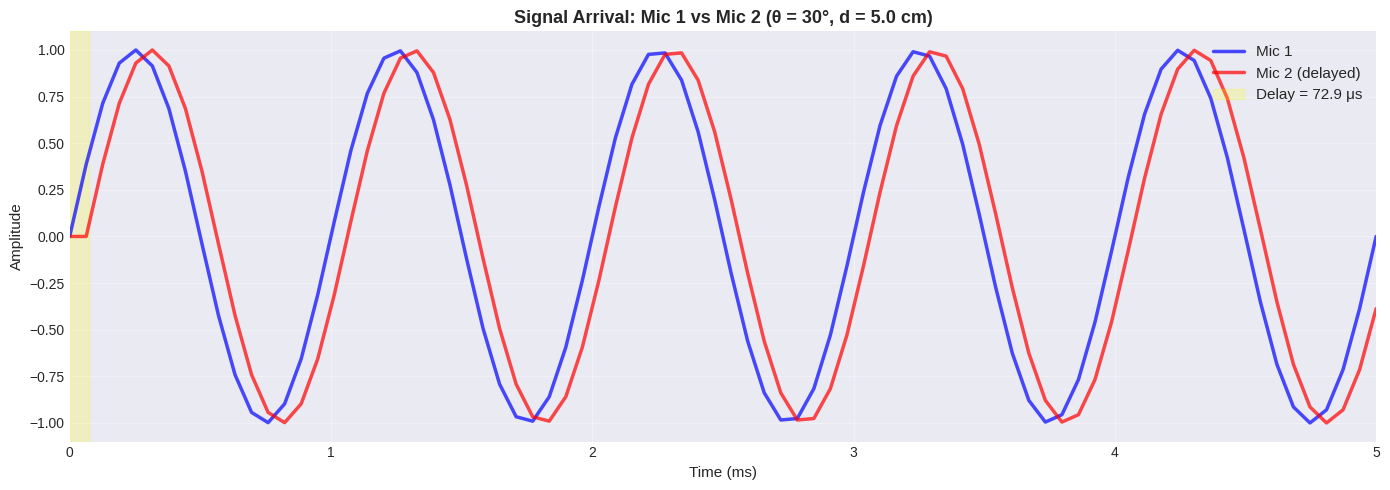


Signal frequency: 1000 Hz
Angle of arrival: 30°
Time delay: 72.89 μs (1 samples)
Phase shift: 26.2°


In [5]:
def visualize_signal_arrival(freq=1000, d=0.05, theta_deg=30, duration=0.005):
    """
    Visualize how a sinusoidal signal arrives at two microphones.
    """
    # Generate signal
    t = np.linspace(0, duration, int(duration * SAMPLE_RATE))
    signal_source = np.sin(2 * np.pi * freq * t)
    
    # Calculate delay
    tau, tau_samples = calculate_time_delay(d, theta_deg)
    
    # Mic 1: receives signal first (reference)
    mic1_signal = signal_source.copy()
    
    # Mic 2: receives delayed signal
    mic2_signal = np.zeros_like(signal_source)
    if tau_samples > 0:
        mic2_signal[tau_samples:] = signal_source[:-tau_samples]
    else:
        mic2_signal = signal_source.copy()
    
    # Plot overlay comparison
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(t * 1000, mic1_signal, linewidth=2.5, color='blue', alpha=0.7, label='Mic 1')
    ax.plot(t * 1000, mic2_signal, linewidth=2.5, color='red', alpha=0.7, label='Mic 2 (delayed)')
    
    # Mark the delay
    if tau_samples > 0:
        ax.axvspan(0, tau * 1000, alpha=0.2, color='yellow', label=f'Delay = {tau*1e6:.1f} μs')
    
    ax.set_xlabel('Time (ms)', fontsize=11)
    ax.set_ylabel('Amplitude', fontsize=11)
    ax.set_title(f'Signal Arrival: Mic 1 vs Mic 2 (θ = {theta_deg}°, d = {d*100:.1f} cm)', 
                 fontsize=13, weight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11, loc='upper right')
    ax.set_xlim([0, duration * 1000])
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSignal frequency: {freq} Hz")
    print(f"Angle of arrival: {theta_deg}°")
    print(f"Time delay: {tau*1e6:.2f} μs ({tau_samples} samples)")
    print(f"Phase shift: {(tau * freq * 360) % 360:.1f}°")

# Visualize
visualize_signal_arrival(freq=1000, d=0.05, theta_deg=30, duration=0.005)

---
## 3. Delay-and-Sum Beamforming

### 3.1 The Core Idea

**Problem**: Signals arrive at different times  
**Solution**: Delay the earlier signal to align them, then sum

```
Mic1: ──[signal]────────────┐
                             ├──→ ADD ──→ Enhanced
Mic2: ──[signal]──[delay]───┘
```

### Mathematical Formulation

**Signal Model:**

$$x_1(t) = s(t) + n_1(t)$$
$$x_2(t) = s(t - \tau) + n_2(t)$$

Where:
- $s(t)$ = desired speech signal (coherent)
- $n_1(t), n_2(t)$ = noise (incoherent, uncorrelated)
- $\tau$ = time delay

**Beamformer Output:**

$$y(t) = \frac{1}{2}[x_1(t) + x_2(t + \tau)]$$

After delay compensation:

$$y(t) = \frac{1}{2}[s(t) + n_1(t) + s(t) + n_2(t)]$$
$$y(t) = s(t) + \frac{1}{2}[n_1(t) + n_2(t)]$$

### Why Does This Reduce Noise?

**For Speech (Coherent):**
- Signal power: $P_s = E[s^2(t)]$
- After summing: $P_{s,out} = E[(2s(t))^2] = 4P_s$ ✓ **Quadruples!**

**For Noise (Incoherent):**
- Noise power at each mic: $P_n = E[n^2(t)]$
- After summing: $P_{n,out} = E[(n_1 + n_2)^2] = E[n_1^2] + E[n_2^2] = 2P_n$ ✓ **Only doubles**

**SNR Improvement:**

$$\text{SNR}_{\text{improvement}} = \frac{4P_s / 2P_n}{P_s / P_n} = 2 = 3 \text{ dB}$$

---

In [6]:
def delay_and_sum_beamformer(mic1, mic2, delay_samples):
    """
    Simple delay-and-sum beamformer.
    
    Args:
        mic1: Signal from microphone 1 [T samples]
        mic2: Signal from microphone 2 [T samples]
        delay_samples: Number of samples to delay mic2
    
    Returns:
        output: Beamformed signal [T samples]
    """
    # Delay mic2 to align with mic1
    if delay_samples > 0:
        mic2_delayed = np.zeros_like(mic2)
        mic2_delayed[delay_samples:] = mic2[:-delay_samples]
    elif delay_samples < 0:
        # Negative delay means mic1 should be delayed
        mic1_delayed = np.zeros_like(mic1)
        mic1_delayed[-delay_samples:] = mic1[:delay_samples]
        mic2_delayed = mic2
        mic1 = mic1_delayed
    else:
        mic2_delayed = mic2
    
    # Sum with equal weights (average)
    output = 0.5 * (mic1 + mic2_delayed)
    
    return output

print("✓ Delay-and-sum beamformer function defined!")

✓ Delay-and-sum beamformer function defined!


### 3.2 Demonstration: Speech + Noise Example

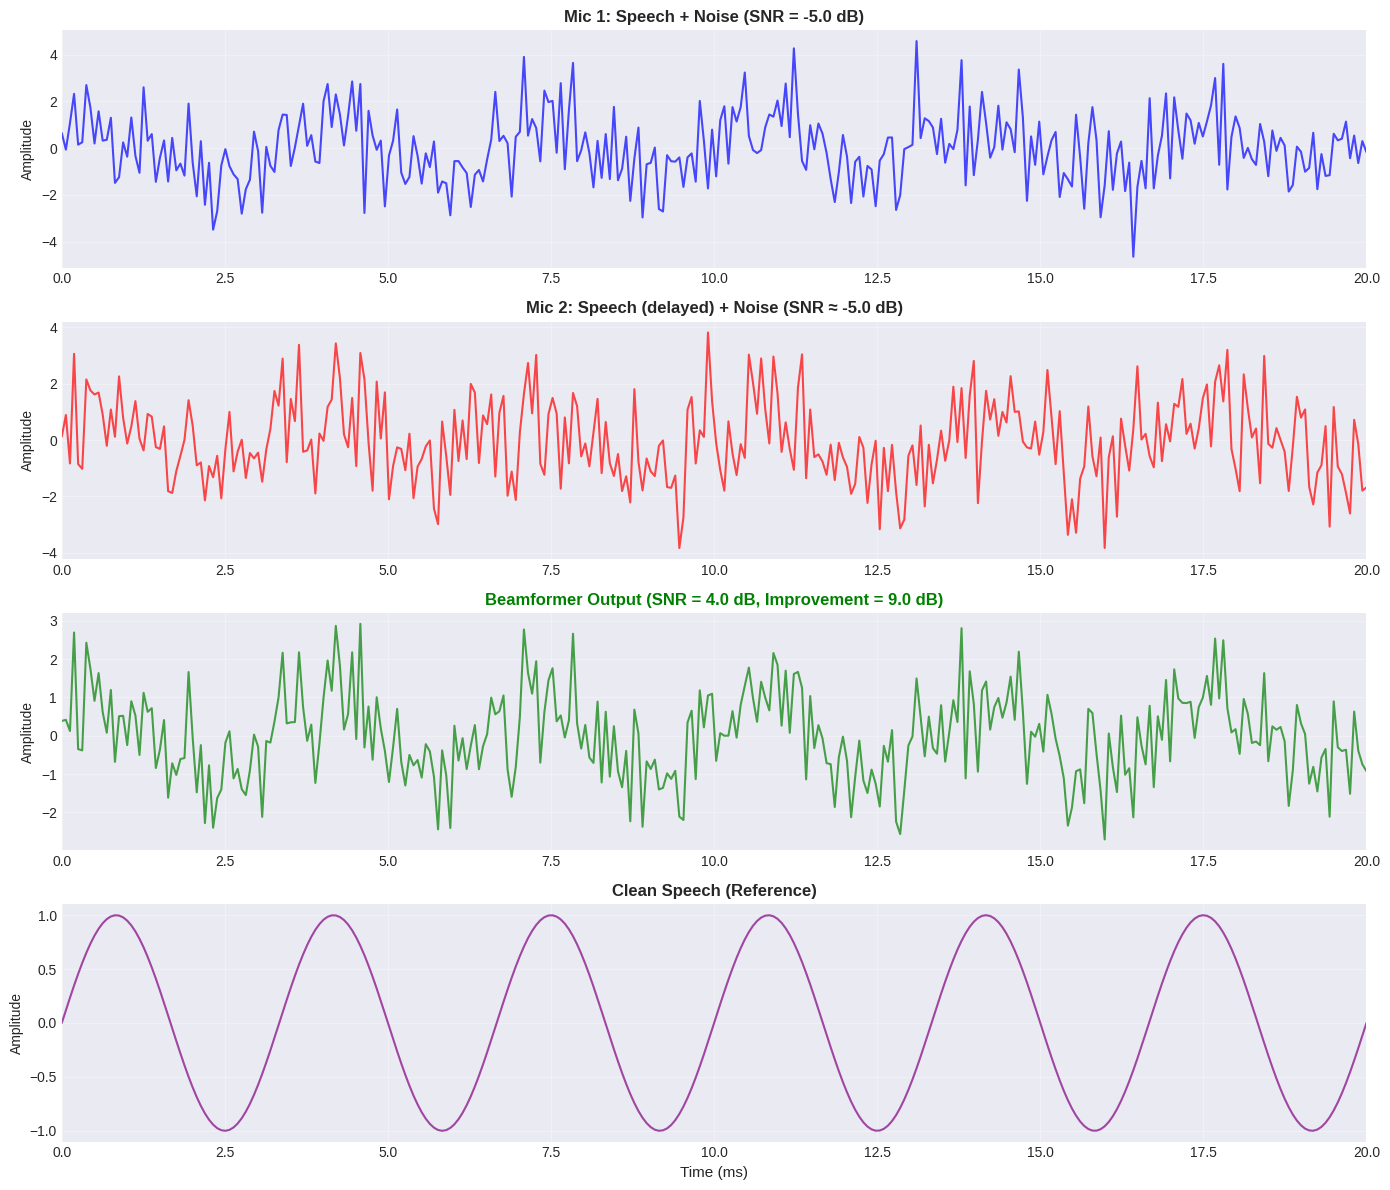

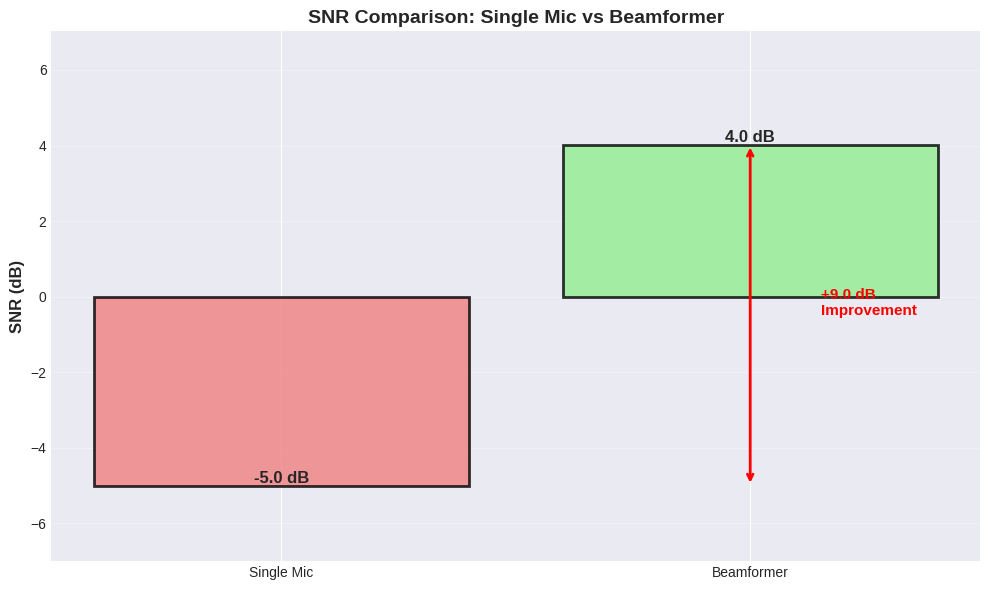


BEAMFORMING RESULTS:
Input SNR (single mic):     -5.00 dB
Output SNR (beamformer):    4.02 dB
SNR Improvement:            9.02 dB
Expected (theory):          ~3.01 dB (for 2 mics)

Why ~3 dB improvement?
  • Speech (coherent): Doubles in amplitude → 4× power (+6 dB)
  • Noise (incoherent): Adds incoherently → 2× power (+3 dB)
  • Net improvement: 6 dB - 3 dB = 3 dB


In [7]:
def demonstrate_delay_and_sum(freq_speech=300, theta_speech=0, d=0.05, duration=0.02, snr_db=-5):
    """
    Demonstrate delay-and-sum beamforming with speech and noise.
    """
    t = np.linspace(0, duration, int(duration * SAMPLE_RATE))
    
    # Generate speech signal (from target direction)
    speech = np.sin(2 * np.pi * freq_speech * t)
    
    # Generate diffuse noise (uncorrelated at each mic)
    np.random.seed(42)
    noise1 = np.random.randn(len(t))
    noise2 = np.random.randn(len(t))  # Different noise
    
    # Scale noise to achieve desired SNR
    speech_power = np.mean(speech**2)
    noise_power = np.mean(noise1**2)
    noise_scale = np.sqrt(speech_power / (noise_power * 10**(snr_db/10)))
    noise1 *= noise_scale
    noise2 *= noise_scale
    
    # Calculate delay for speech direction
    tau, tau_samples = calculate_time_delay(d, theta_speech)
    
    # Create delayed speech for mic2
    speech_delayed = np.zeros_like(speech)
    if tau_samples > 0:
        speech_delayed[tau_samples:] = speech[:-tau_samples]
    else:
        speech_delayed = speech.copy()
    
    # Microphone signals
    mic1 = speech + noise1
    mic2 = speech_delayed + noise2
    
    # Apply beamformer
    output = delay_and_sum_beamformer(mic1, mic2, tau_samples)
    
    # Calculate SNRs
    def calculate_snr(signal, noise):
        return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))
    
    snr_mic1 = calculate_snr(speech, noise1)
    
    # For output, speech is doubled, noise is averaged
    speech_out = 2 * speech  # After alignment and summing
    noise_out = 0.5 * (noise1 + noise2)
    snr_out = calculate_snr(speech_out, noise_out)
    
    improvement = snr_out - snr_mic1
    
    # Plot
    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    
    # Mic 1
    axes[0].plot(t * 1000, mic1, linewidth=1.5, color='blue', alpha=0.7)
    axes[0].set_ylabel('Amplitude', fontsize=10)
    axes[0].set_title(f'Mic 1: Speech + Noise (SNR = {snr_mic1:.1f} dB)', 
                      fontsize=12, weight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([0, duration * 1000])
    
    # Mic 2
    axes[1].plot(t * 1000, mic2, linewidth=1.5, color='red', alpha=0.7)
    axes[1].set_ylabel('Amplitude', fontsize=10)
    axes[1].set_title(f'Mic 2: Speech (delayed) + Noise (SNR ≈ {snr_mic1:.1f} dB)', 
                      fontsize=12, weight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([0, duration * 1000])
    
    # Beamformer output
    axes[2].plot(t * 1000, output, linewidth=1.5, color='green', alpha=0.7)
    axes[2].set_ylabel('Amplitude', fontsize=10)
    axes[2].set_title(f'Beamformer Output (SNR = {snr_out:.1f} dB, Improvement = {improvement:.1f} dB)', 
                      fontsize=12, weight='bold', color='green')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlim([0, duration * 1000])
    
    # Clean speech for reference
    axes[3].plot(t * 1000, speech, linewidth=1.5, color='purple', alpha=0.7)
    axes[3].set_xlabel('Time (ms)', fontsize=11)
    axes[3].set_ylabel('Amplitude', fontsize=10)
    axes[3].set_title('Clean Speech (Reference)', fontsize=12, weight='bold')
    axes[3].grid(True, alpha=0.3)
    axes[3].set_xlim([0, duration * 1000])
    
    plt.tight_layout()
    plt.show()
    
    # SNR comparison
    fig, ax = plt.subplots(figsize=(10, 6))
    
    categories = ['Single Mic', 'Beamformer']
    snrs = [snr_mic1, snr_out]
    colors = ['lightcoral', 'lightgreen']
    
    bars = ax.bar(categories, snrs, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
    
    # Add value labels
    for bar, snr in zip(bars, snrs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{snr:.1f} dB', ha='center', va='bottom', fontsize=12, weight='bold')
    
    # Add improvement annotation
    ax.annotate('', xy=(1, snr_out), xytext=(1, snr_mic1),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text(1.15, (snr_mic1 + snr_out)/2, f'+{improvement:.1f} dB\nImprovement',
            fontsize=11, weight='bold', color='red')
    
    ax.set_ylabel('SNR (dB)', fontsize=12, weight='bold')
    ax.set_title('SNR Comparison: Single Mic vs Beamformer', fontsize=14, weight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([min(snrs) - 2, max(snrs) + 3])
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("BEAMFORMING RESULTS:")
    print("="*70)
    print(f"Input SNR (single mic):     {snr_mic1:.2f} dB")
    print(f"Output SNR (beamformer):    {snr_out:.2f} dB")
    print(f"SNR Improvement:            {improvement:.2f} dB")
    print(f"Expected (theory):          ~3.01 dB (for 2 mics)")
    print("="*70)
    print("\nWhy ~3 dB improvement?")
    print("  • Speech (coherent): Doubles in amplitude → 4× power (+6 dB)")
    print("  • Noise (incoherent): Adds incoherently → 2× power (+3 dB)")
    print("  • Net improvement: 6 dB - 3 dB = 3 dB")

# Demonstrate
demonstrate_delay_and_sum(freq_speech=300, theta_speech=0, snr_db=-5)

---
## 4. Beam Patterns: Visualizing Directivity

### 4.1 What is a Beam Pattern?

A **beam pattern** shows the beamformer's **sensitivity** (gain) as a function of angle.

- **Main lobe**: High gain (target direction)
- **Side lobes**: Unwanted sensitivity
- **Nulls**: Zero sensitivity (rejected directions)

### Mathematical Definition

For a 2-mic delay-and-sum beamformer steered to angle $\theta_0$:

$$B(\theta, f) = \left| \frac{1 + e^{-j2\pi f \tau(\theta)}}{2} \right|$$

Where:
- $\tau(\theta) = \frac{d \cdot \sin(\theta)}{c}$ = time delay from angle $\theta$
- $f$ = frequency



---

In [8]:
def compute_beam_pattern(d, freq, theta_steer=0, num_angles=360):
    """
    Compute beam pattern for a 2-mic delay-and-sum beamformer.
    
    Args:
        d: Microphone spacing (meters)
        freq: Frequency (Hz)
        theta_steer: Steering angle (degrees)
        num_angles: Number of angles to evaluate
    
    Returns:
        angles: Array of angles (degrees)
        pattern: Beam pattern (linear scale)
        pattern_db: Beam pattern (dB scale)
    """
    angles = np.linspace(-180, 180, num_angles)
    pattern = np.zeros(num_angles)
    
    # Steering delay
    tau_steer = (d * np.sin(np.radians(theta_steer))) / SPEED_OF_SOUND
    
    for i, theta in enumerate(angles):
        # Delay from this angle
        tau = (d * np.sin(np.radians(theta))) / SPEED_OF_SOUND
        
        # Relative delay (after steering compensation)
        tau_rel = tau - tau_steer
        
        # Beam pattern (magnitude of array response)
        # For 2 mics: |1 + e^(-j*2*pi*f*tau)| / 2
        response = (1 + np.exp(-1j * 2 * np.pi * freq * tau_rel)) / 2
        pattern[i] = np.abs(response)
    
    # Convert to dB
    pattern_db = 20 * np.log10(pattern + 1e-10)
    
    return angles, pattern, pattern_db

print("✓ Beam pattern computation function defined!")

✓ Beam pattern computation function defined!


### 4.2 Polar Plot: Classic Beam Pattern Visualization

Beam Pattern at 1 kHz:


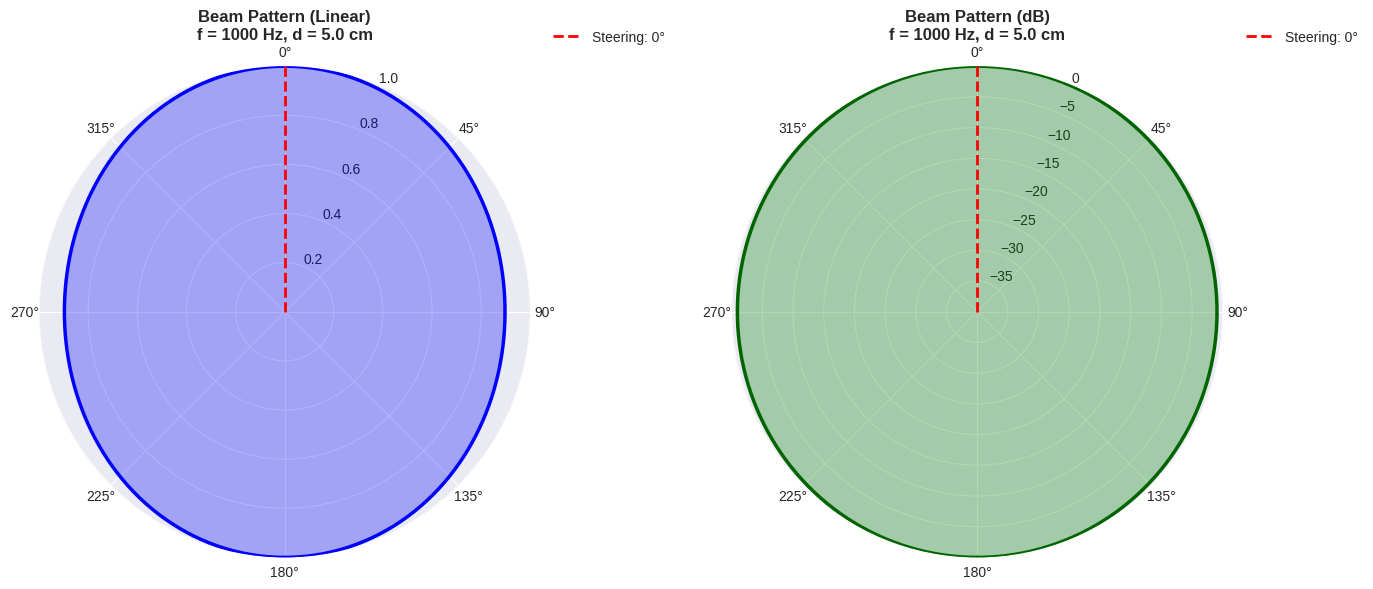

In [9]:
def plot_beam_pattern_polar(d=0.05, freq=1000, theta_steer=0):
    """
    Plot beam pattern in polar coordinates.
    """
    angles, pattern, pattern_db = compute_beam_pattern(d, freq, theta_steer)
    
    # Convert angles to radians for polar plot
    angles_rad = np.radians(angles)
    
    fig = plt.figure(figsize=(14, 6))
    
    # Left: Linear scale
    ax1 = fig.add_subplot(121, projection='polar')
    ax1.plot(angles_rad, pattern, linewidth=2.5, color='blue')
    ax1.fill(angles_rad, pattern, alpha=0.3, color='blue')
    ax1.set_theta_zero_location('N')  # 0° at top
    ax1.set_theta_direction(-1)  # Clockwise
    ax1.set_title(f'Beam Pattern (Linear)\nf = {freq} Hz, d = {d*100:.1f} cm', 
                  fontsize=12, weight='bold', pad=20)
    ax1.set_ylim([0, 1])
    ax1.grid(True)
    
    # Mark steering direction
    ax1.plot([np.radians(theta_steer), np.radians(theta_steer)], [0, 1], 
             'r--', linewidth=2, label=f'Steering: {theta_steer}°')
    ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    # Right: dB scale
    ax2 = fig.add_subplot(122, projection='polar')
    ax2.plot(angles_rad, pattern_db, linewidth=2.5, color='darkgreen')
    ax2.fill(angles_rad, pattern_db, alpha=0.3, color='green')
    ax2.set_theta_zero_location('N')
    ax2.set_theta_direction(-1)
    ax2.set_title(f'Beam Pattern (dB)\nf = {freq} Hz, d = {d*100:.1f} cm', 
                  fontsize=12, weight='bold', pad=20)
    ax2.set_ylim([-40, 0])
    ax2.grid(True)
    
    # Mark steering direction
    ax2.plot([np.radians(theta_steer), np.radians(theta_steer)], [-40, 0], 
             'r--', linewidth=2, label=f'Steering: {theta_steer}°')
    ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    plt.tight_layout()
    plt.show()

# Plot for different frequencies
print("Beam Pattern at 1 kHz:")
plot_beam_pattern_polar(d=0.05, freq=1000, theta_steer=0)

### 4.3 Frequency Dependence of Beam Patterns

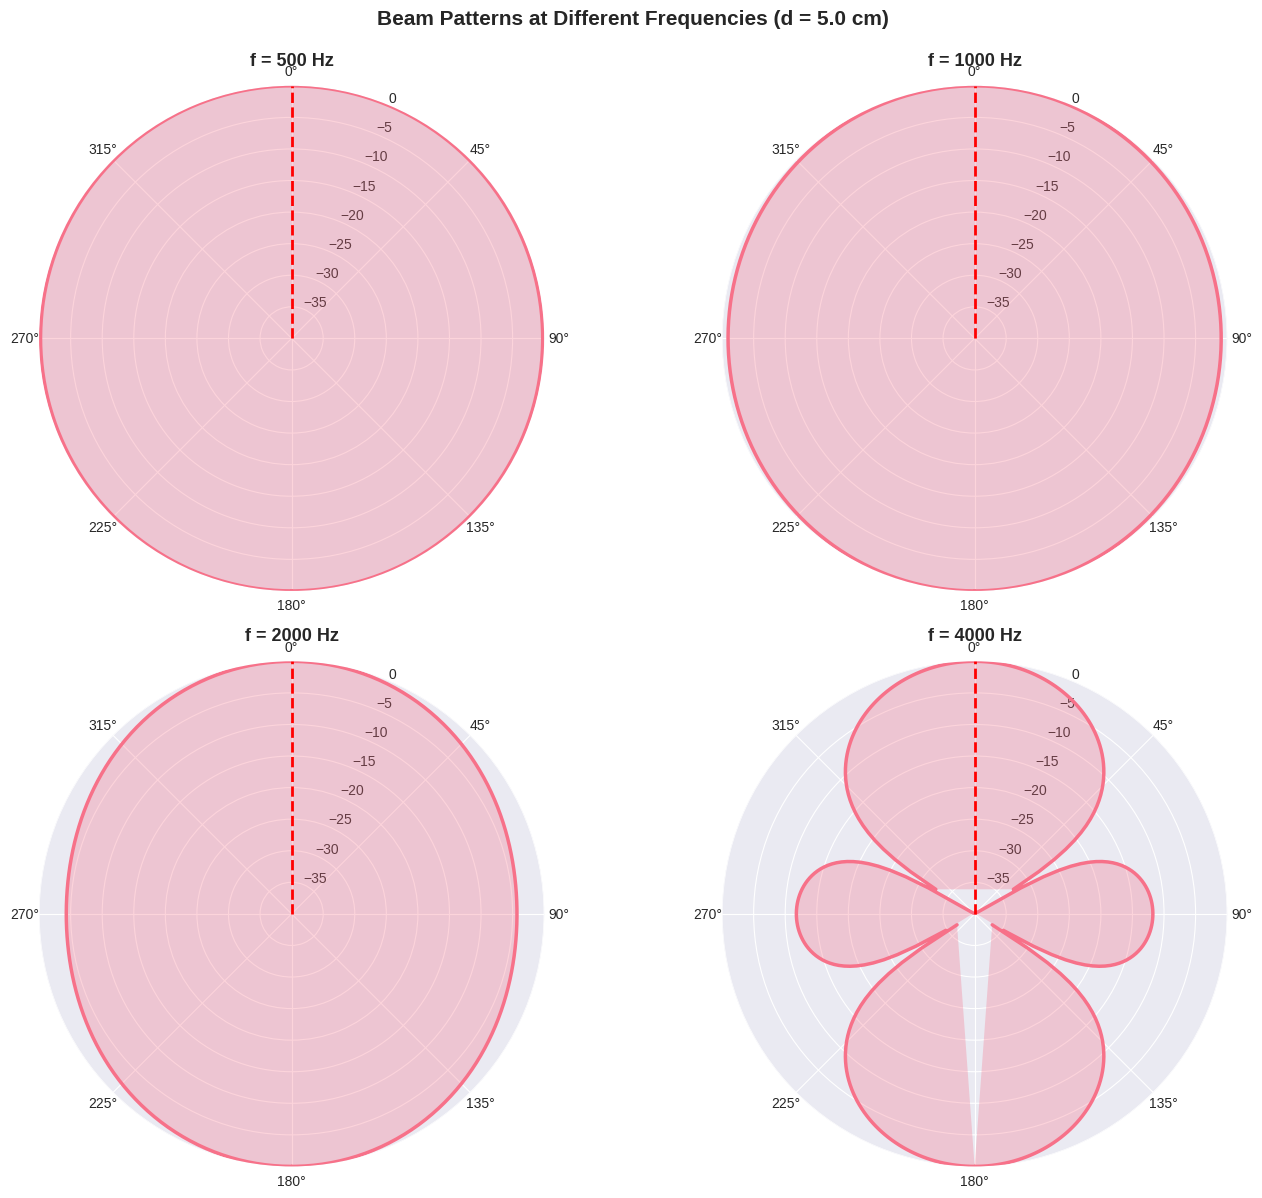


Key Observations:
  • Lower frequencies → Wider main lobe (less directional)
  • Higher frequencies → Narrower main lobe (more directional)
  • Higher frequencies → More side lobes

Why? Wavelength λ = c/f:
  • At 500 Hz: λ = 0.69 m (much larger than d = 0.05 m)
  • At 4000 Hz: λ = 0.086 m (comparable to d = 0.05 m)


In [10]:
def plot_beam_patterns_multiple_frequencies(d=0.05, theta_steer=0):
    """
    Plot beam patterns for multiple frequencies.
    """
    frequencies = [500, 1000, 2000, 4000]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(projection='polar'))
    axes = axes.flatten()
    
    for idx, freq in enumerate(frequencies):
        angles, pattern, pattern_db = compute_beam_pattern(d, freq, theta_steer)
        angles_rad = np.radians(angles)
        
        ax = axes[idx]
        ax.plot(angles_rad, pattern_db, linewidth=2.5)
        ax.fill(angles_rad, pattern_db, alpha=0.3)
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)
        ax.set_title(f'f = {freq} Hz', fontsize=13, weight='bold', pad=15)
        ax.set_ylim([-40, 0])
        ax.grid(True)
        
        # Mark steering direction
        ax.plot([np.radians(theta_steer), np.radians(theta_steer)], [-40, 0], 
                'r--', linewidth=2)
    
    plt.suptitle(f'Beam Patterns at Different Frequencies (d = {d*100:.1f} cm)', 
                 fontsize=15, weight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print("\nKey Observations:")
    print("  • Lower frequencies → Wider main lobe (less directional)")
    print("  • Higher frequencies → Narrower main lobe (more directional)")
    print("  • Higher frequencies → More side lobes")
    print("\nWhy? Wavelength λ = c/f:")
    print(f"  • At 500 Hz: λ = {SPEED_OF_SOUND/500:.2f} m (much larger than d = {d} m)")
    print(f"  • At 4000 Hz: λ = {SPEED_OF_SOUND/4000:.3f} m (comparable to d = {d} m)")

plot_beam_patterns_multiple_frequencies(d=0.05, theta_steer=0)

---
## 5. Summary and Key Takeaways

### What We Learned:

1. **Time Delays**: Sound arrives at different mics at different times based on geometry
   - $\tau = \frac{d \cdot \sin(\theta)}{c}$

2. **Delay-and-Sum**: Align signals by compensating for delays, then average
   - Speech (coherent): Doubles → +6 dB
   - Noise (incoherent): Increases by √2 → +3 dB
   - **Net improvement: ~3 dB for 2 mics**

3. **Beam Patterns**: Show directional sensitivity
   - Main lobe points toward target
   - Frequency-dependent (higher freq = narrower beam)

4. **Limitations**:
   - Fixed pattern (can't adapt to moving sources)
   - Limited noise rejection (~3 dB)
   - Doesn't handle directional noise well

### Next Steps:

For better performance, we need **Adaptive Beamforming** (MVDR):
- Learns noise statistics
- Creates adaptive nulls
- Can achieve 10-20 dB improvement!

See the companion notebook: `5_a_a_i_Understanding_adaptiveMVDRBeamforming_and_relatedQnAs.ipynb`

---

## Q&A Section

### Q1: Why does delay-and-sum only give 3 dB improvement?

**A**: Because noise is incoherent (uncorrelated between mics):
- Speech adds coherently: 1 + 1 = 2 (amplitude) → 4× power
- Noise adds incoherently: √(1² + 1²) = √2 (RMS) → 2× power
- Ratio: 4/2 = 2 = 3 dB improvement

### Q2: What if noise comes from the same direction as speech?

**A**: Then beamforming doesn't help! The noise is also coherent and gets enhanced just like speech. This is why we need adaptive methods (MVDR) that can create nulls in specific directions.

### Q3: Why do beam patterns change with frequency?

**A**: Because the phase shift depends on frequency:
- Phase shift = 2πfτ
- Higher frequency → larger phase shift for same delay
- This creates narrower beams at high frequencies

### Q4: Can we use more than 2 microphones?

**A**: Yes! With M microphones:
- SNR improvement ≈ 10·log₁₀(M) dB
- 4 mics → 6 dB, 8 mics → 9 dB
- But diminishing returns and increased complexity

---